In [1]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import pdist
from sklearn.gaussian_process.kernels import Matern
import torch
import torch.nn as nn
import gpytorch
from torch import tensor as tt

import sys as sys
import os
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
import pickle
import math 
import re
from scipy.spatial import distance_matrix
from sklearn.metrics.pairwise import euclidean_distances 
import pandas as pd
from scipy.optimize import dual_annealing
from joblib import Parallel, delayed
import psutil
from scipy.spatial.distance import pdist
from sklearn.metrics import pairwise_distances
from sklearn.gaussian_process.kernels import Matern
import netCDF4 as nc


I run Python 3.9.10. 

# Utility function:

In [2]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

def torch_Matern_05(dist_matrix, rho):
    K = torch.exp(-dist_matrix / rho)
    return K

def sample_Gauss_fixed_noise(fixed_noise, chol_cov):
    return fixed_noise @ chol_cov.T

norm = torch.distributions.Normal(0.0, 1.0)


# Minimal example for help with debugging

In [3]:
n_loc = 3

true_theta = tt(70., dtype=torch.float64)
true_a = tt(50., dtype=torch.float64)

# Define distance matrix -> covariance matrix -> observe from multivariate normal -> censor
locations = tt([[i * 10, i * 10] for i in range(n_loc)], dtype=torch.float64)
topo = torch.sin(locations.mean(dim=1)/30)**2 *4
dist_3d = torch.column_stack([locations, true_a * topo])
dist_matrix = torch.cdist(dist_3d, dist_3d)
true_cov = torch_Matern_05(dist_matrix, true_theta)

latent_z = sample_Gauss_fixed_noise(norm.sample((5000, true_cov.shape[0])).to(dtype=torch.float64), torch.linalg.cholesky(true_cov))
copula_u = norm.cdf(latent_z)

# Observations
censor_levels = torch.rand(latent_z.shape[1])
latent_z_censored = torch.maximum(latent_z, norm.icdf(censor_levels))
copula_u_censored = torch.maximum(copula_u, censor_levels)


###
#Optimisation
###

SR_u = [] # keep track of SR values - theta, a, SR

fixed_noise = norm.sample((2000,latent_z.shape[1])).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

# initialise params
theta = tt(30.,requires_grad=True)
a_ = tt(30.,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta, a_], lr=10)
# comparing on the copula u-space
for epoch in tqdm(range(500)):
    optimizer.zero_grad()
    # construct current guess of the Distance Matrix
    estimated_dist_3d = torch.column_stack([locations, a_ * topo])
    est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
    # construct current guess of the covariance matrix
    est_cov = torch_Matern_05(est_dist_matrix, theta)
    # sample from the current guess of the covariance matrix using Cholesky decomposition
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov) # on the Gaussian Z-space
    sims_u = norm.cdf(sims_z) # convert to U-space
    sims_u = torch.maximum(sims_u, censor_levels) # censor

    loss = Energy_Score(0.5, copula_u_censored, sims_u)
    loss.backward()
    if epoch % 50 == 0: # print for sanity check
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}, a Gradient = {a_.grad.item()}, a = {a_.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_u.append([theta.item(),a_.item(),loss.item()])




# Plotting
SR_u_array = np.array(SR_u)
# Initialize the result array
theta_values = torch.linspace(10, 100, 20)
a_values = torch.linspace(10, 100, 20)
energy_scores = np.zeros((len(theta_values), len(a_values)))
# Compute the energy scores for each combination of theta and a_
for i, theta in enumerate(tqdm(theta_values)):
    for j, a_ in enumerate(a_values):
        estimated_dist_3d = torch.column_stack([locations, a_ * topo])
        est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
        est_cov = torch_Matern_05(est_dist_matrix, theta)
        chol_cov = torch.linalg.cholesky(est_cov)
        sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
        sims_u = norm.cdf(sims_z)
        sims_u = torch.maximum(sims_u, censor_levels)
        loss = Energy_Score(0.5, copula_u_censored, sims_u)
        energy_scores[i, j] = loss.item()

# Create the contour plot
X, Y = np.meshgrid(a_values.numpy(), theta_values.numpy())
plt.contourf(X, Y, np.power(energy_scores, 1/5), cmap='viridis', levels=30)
plt.colorbar(label='Energy Score')
plt.xlabel('a_')
plt.ylabel('theta')
plt.title('Contour plot of Energy Scores')
SR_u_np = np.array(SR_u)
scatter = plt.scatter(SR_u_np[:, 1], SR_u_np[:, 0], c=np.arange(len(SR_u_np)), cmap='coolwarm', edgecolor='k')
plt.scatter(true_a, true_theta, c='red', marker='x',label='True Parameters')
plt.show()


estimated_dist_3d = torch.column_stack([locations, a_ * topo])
est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
est_cov = torch_Matern_05(est_dist_matrix, theta)
est_cov_np = est_cov.detach().numpy()
true_cov_np = true_cov.detach().numpy()

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
# Plot the estimated covariance matrix
cax1 = ax1.matshow(est_cov_np, cmap='viridis')
fig.colorbar(cax1, ax=ax1)
ax1.set_title(f'Estimated Covariance Matrix \n (Theta = {SR_u[-1][0].__round__(1)}, a = {SR_u[-1][1].__round__(1)})')
# Add numbers over each cell
for (i, j), val in np.ndenumerate(est_cov_np):
    ax1.text(j, i, f'{val:.2f}', ha='center', va='center', color='white')
# Plot the true covariance matrix
cax2 = ax2.matshow(true_cov_np, cmap='viridis')
fig.colorbar(cax2, ax=ax2)
ax2.set_title(f'True Covariance Matrix \n (Theta = {true_theta.item()}, a = {true_a.item()})')
# Add numbers over each cell
for (i, j), val in np.ndenumerate(true_cov_np):
    ax2.text(j, i, f'{val:.2f}', ha='center', va='center', color='white')
plt.show()

  0%|          | 1/500 [00:00<06:40,  1.25it/s]

Epoch 0: Loss = 0.613307968845524, Theta Gradient = -9.053697431227192e-05, Theta = 30.0, a Gradient = 5.8682478993432596e-05, a = 30.0


 10%|▉         | 48/500 [00:27<04:16,  1.76it/s]


KeyboardInterrupt: 

# Real data

In [ ]:
#################################################################### Loading GNM ####################################################################
sys.path.append('../')

import pickle


GNM_output = pickle.load( open("trainset_output_1999-07_2019-07.pkl","rb") )
#################################################################### Problematic locations? ###############################################################

location_keys = list(GNM_output.keys())                 # '([0, 16], [44, 60])', ...
output_keys = list(GNM_output[location_keys[0]].keys()) # 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'date', 5'pred_p', 6'mask', 7'idx_loc_in_region'

# May have to remove a location that doesn't have the correct number of days:
location_keys.remove(location_keys[344]) #to remove for gamma_20_20 train  
#################################################################### Utility functions ####################################################################
def give_lat_lon(location_key):
    return [ int(re.findall(r'\d+',string)[0]) for string in location_key.split(',')]

def is_loc_land(location,row,column):
    return GNM_output[location]['mask'][0][row][column]

#location_keys.remove('lat_50.95_49.35_lon_-4.55_-2.95') # 'lat_50.95_49.35_lon_-4.55_-2.95' has no data after week indexed 255, so I did not consider it.
day_dates = [pd.to_datetime(i).date() for i in GNM_output[location_keys[0]]['date']]
output_keys.remove('idx_loc_in_region') # not usefull
output_keys.remove('date') # no more usefull

#################################################################### Making list for land locations ####################################################################
#GNM_landonly[location][param][day]
# 0'pred_mu', 1'pred_disp', 2'target_did_rain', 3'target_rain_value', 4'pred_p', 5'location'

GNM_landonly = [] 
land_counter = -1
for location in tqdm(location_keys):
    for col in range(4):
        for row in range(4):
            if not is_loc_land(location,row,col):#check if land
               continue  
            land_counter+=1
            GNM_landonly.append([[],[],[],[],[]]) # parameters except location
            temp_lat_lon = give_lat_lon(location)
            GNM_landonly[land_counter].append([temp_lat_lon[1]-8+row,(temp_lat_lon[2])+6+col]) #location
            for param_idx,param in enumerate(output_keys[:-1]):
                for day in range(len(GNM_output[location_keys[0]]['pred_mu'])):
                    qqq = [location,param,day,row,col]
                    GNM_landonly[land_counter][param_idx].append(GNM_output[location][param][day][row,col])

dist_mat = distance_matrix(np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),np.matrix([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]))

#################################################################### Elevation data ####################################################################
fn = 'topo_0.1_degree.nc'
ds = nc.Dataset(fn)
h = ds['Band1'][:]
h = np.flip(np.matrix(h),axis=0)
topo_dist = euclidean_distances(np.array([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1))

# load obs_norm_all and censor_levels_di
obs_norm_all = np.load('obs_norm_all_train.npy')
censor_levels_di = np.load('censor_levels_di_train.npy')
censor_levels_u = scs.norm.cdf(censor_levels_di)

100%|██████████| 344/344 [01:24<00:00,  4.09it/s]


## Simulated experiment

200


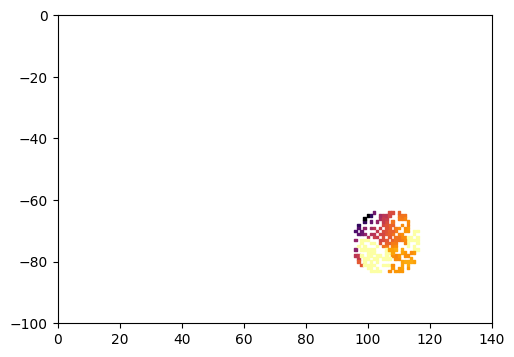

In [78]:
def generate_subsample_locs(locs_nb):
    locs=[]
    while len(locs)<locs_nb:
        #random_center = np.random.choice(range(len(GNM_landonly))) 
        random_center = 3532  
        locs = np.where([math.dist(GNM_landonly[k][5],GNM_landonly[random_center ][5])<(np.sqrt(locs_nb/np.pi)+3) for k in range(len(GNM_landonly))])[0]
    return np.random.choice(locs,size=locs_nb,replace=False)    

fig = plt.gcf() 
fig.set_size_inches(5.6,4)
locs = generate_subsample_locs(locs_nb=200)
print(len(locs))

plt.scatter([GNM_landonly[loc][5][1] for loc in locs],
[-GNM_landonly[loc][5][0] for loc in locs],
c=[GNM_landonly[loc][3][300] for loc in locs],
cmap='inferno_r',s=3,marker='s')

plt.xlim(0,140)
plt.ylim(-100,0)
plt.show()

In [6]:
true_theta = tt(70., dtype=torch.float64)
true_a = tt(50., dtype=torch.float64)

# Define distance matrix -> covariance matrix -> observe from multivariate normal -> censor
dist_3d = torch.column_stack([locations, true_a * topo])
dist_matrix = torch.cdist(dist_3d, dist_3d)
true_cov = torch_Matern_05(dist_matrix, true_theta)

latent_z = sample_Gauss_fixed_noise(norm.sample((5000, true_cov.shape[0])).to(dtype=torch.float64), torch.linalg.cholesky(true_cov))
copula_u = norm.cdf(latent_z)

# Observations
censor_levels = torch.rand(latent_z.shape[1])
latent_z_censored = torch.maximum(latent_z, norm.icdf(censor_levels))
copula_u_censored = torch.maximum(copula_u, censor_levels)

In [85]:
fake_theta = tt(40.,requires_grad=True)
fake_a_ = tt(0.005,requires_grad=True)

fake_dist_3D = torch.column_stack([
    tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in locs]),
    fake_a_*tt([h[loc[5][0],loc[5][1]+2] for loc in [GNM_landonly[l] for l in locs]]).reshape(-1,1)])
fake_dist_matrix = torch.cdist(fake_dist_3D, fake_dist_3D)
fake_cov = torch_Matern_05(fake_dist_matrix, fake_theta)

fixed_moise_sims = norm.sample((400,fake_cov.shape[0])).to(dtype=torch.float64)
fake_data = sample_Gauss_fixed_noise(fixed_moise_sims, torch.linalg.cholesky(fake_cov))


In [73]:
Energy_Score(0.5, copula_u_censored, sims_u)

RuntimeError: The size of tensor a (3) must match the size of tensor b (200) at non-singleton dimension 2

In [87]:
torch.maximum(fake_data, norm.icdf(tt(censor_levels_u[400,locs]))).shape

torch.Size([400, 200])

In [70]:
fake_data = norm.cdf(fake_data[:,:200])
fake_data_censored = torch.maximum(fake_data, norm.icdf(tt(censor_levels_u[400,locs])))

###
# Optimisation
###

fixed_noise = fixed_moise_sims[:,:200]#norm.sample((2000,fake_data.shape[1])).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

# initialise params
theta = tt(30.,requires_grad=True)
a_ = tt(0.001,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta, a_], lr=10)
# comparing on the copula u-space
for epoch in tqdm(range(50)):
    optimizer.zero_grad()
    # construct current guess of the Distance Matrix
    estimated_dist_3d = torch.column_stack([
    tt([[GNM_landonly[loc][5][0],GNM_landonly[loc][5][1]] for loc in range(len(GNM_landonly))]),
    10*tt([h[loc[5][0],loc[5][1]+2] for loc in GNM_landonly]).reshape(-1,1)])[:200]
    est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
    # construct current guess of the covariance matrix
    est_cov = torch_Matern_05(est_dist_matrix, theta)
    # sample from the current guess of the covariance matrix using Cholesky decomposition
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov) # on the Gaussian Z-space
    sims_u = norm.cdf(sims_z) # convert to U-space
    

100%|██████████| 50/50 [00:00<00:00, 83.84it/s]


In [146]:
###
#Optimisation
###

SR_u = [] # keep track of SR values - theta, a, SR

fixed_noise = norm.sample((2000,latent_z.shape[1])).to(dtype=torch.float64) # fixed noise for sampling with different covariance matrices

# initialise params
theta = tt(30.,requires_grad=True)
a_ = tt(30.,requires_grad=True)

# Define the optimizers
optimizer = torch.optim.Adam([theta, a_], lr=10)
# comparing on the copula u-space
for epoch in tqdm(range(500)):
    optimizer.zero_grad()
    # construct current guess of the Distance Matrix
    estimated_dist_3d = torch.column_stack([locations, a_ * topo])
    est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
    # construct current guess of the covariance matrix
    est_cov = torch_Matern_05(est_dist_matrix, theta)
    # sample from the current guess of the covariance matrix using Cholesky decomposition
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov) # on the Gaussian Z-space
    sims_u = norm.cdf(sims_z) # convert to U-space
    sims_u = torch.maximum(sims_u, censor_levels) # censor

    loss = Energy_Score(0.5, copula_u_censored, sims_u)
    loss.backward()
    if epoch % 50 == 0: # print for sanity check
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}, a Gradient = {a_.grad.item()}, a = {a_.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_u.append([theta.item(),a_.item(),loss.item()])

torch.Size([400, 4087])

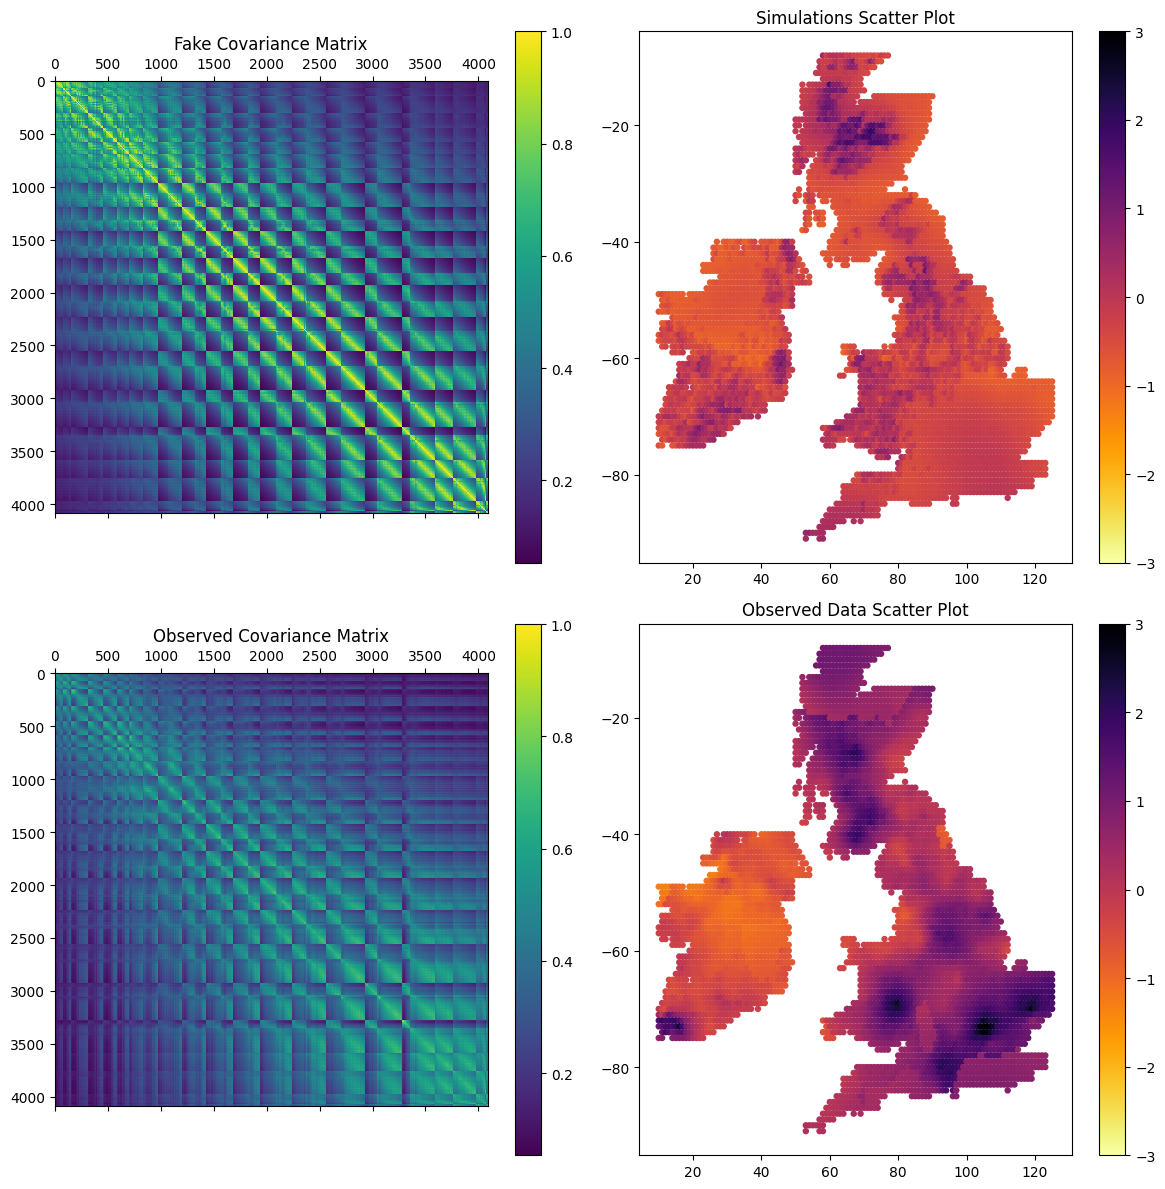

In [13]:

fig, axs = plt.subplots(2, 2, figsize=(12, 12))
# Plot fake covariance matrix
axs[0, 0].matshow(fake_cov.detach().numpy())
axs[0, 0].set_title('Fake Covariance Matrix')
fig.colorbar(axs[0, 0].matshow(fake_cov.detach().numpy()), ax=axs[0, 0])

# Plot scatter plot of simulations
sc = axs[0, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
[-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], c=sims_censored[1].detach().numpy(), cmap='inferno_r',vmin=-3, vmax=3,s=13)
axs[0, 1].set_title('Simulations Scatter Plot')
fig.colorbar(sc, ax=axs[0, 1])

# Plot observed covariance matrix
obs_cov = np.cov(obs_norm_all.T) / 1.119
axs[1, 0].matshow(obs_cov)
axs[1, 0].set_title('Observed Covariance Matrix')
fig.colorbar(axs[1, 0].matshow(obs_cov), ax=axs[1, 0])

# Plot observed data
sc_obs = axs[1, 1].scatter([GNM_landonly[loc][5][1] for loc in range(len(GNM_landonly))],
[-GNM_landonly[loc][5][0] for loc in range(len(GNM_landonly))], c=obs_norm_all[1], cmap='inferno_r',vmin=-3, vmax=3,s=13)
axs[1, 1].set_title('Observed Data Scatter Plot')
fig.colorbar(sc_obs, ax=axs[1, 1])

plt.tight_layout()
plt.show()

In [9]:
import plotly.graph_objects as go
import numpy as np
from scipy.interpolate import griddata
from scipy.spatial import cKDTree

# Assuming fake_dist_3D and obs_norm_all are already defined
# fake_dist_3D: shape (n, 3)
# obs_norm_all: shape (1, n)
a_guess =0.005
# Convert tensors to numpy arrays
fake_dist_3D_np = fake_dist_3D.detach().numpy()
obs_norm_all_np = obs_norm_all

# Extract x, y, z coordinates and color values
x, y, z = fake_dist_3D_np[:, 0], fake_dist_3D_np[:, 1], fake_dist_3D_np[:, 2]
color = obs_norm_all_np[0]

# Create a grid for interpolation
grid_x, grid_y = np.meshgrid(
    np.linspace(x.min(), x.max(), 100),
    np.linspace(y.min(), y.max(), 100)
)

# Interpolate z values on the grid using cubic interpolation
grid_z = griddata((x, y), z, (grid_x, grid_y), method='linear')
grid_color = griddata((x, y), color, (grid_x, grid_y), method='linear')

# Create a KDTree for the original points
tree = cKDTree(np.c_[x, y])

# Compute the distance from each grid point to the nearest original point
distances, _ = tree.query(np.c_[grid_x.ravel(), grid_y.ravel()])
distances = distances.reshape(grid_x.shape)

# Create a mask to only show the surface close to the points
mask = distances < 3  # Adjust the threshold as needed

# Apply the mask to the interpolated values
masked_grid_z = np.where(mask, grid_z, np.nan)
masked_grid_color =np.where(mask, grid_color, np.nan)

# Create a 3D surface plot
fig = go.Figure(data=[go.Surface(
    x=grid_x,
    y=grid_y,
    z=masked_grid_z*a_guess,
    surfacecolor=np.zeros(masked_grid_color.shape),
    colorscale='Greys'
)])

# Add the original scatter points
fig.add_trace(go.Scatter3d(
    x=x,
    y=y,
    z=z*a_guess,
    mode='markers',
    marker=dict(
        size=3,
        color=color,  # set color to an array/list of desired values
        colorscale='inferno_r',  # choose a colorscale
        opacity=0.8
    )
))

# Tight layout and fix z-axis limits
fig.update_layout(
    title='3D Surface Plot with Masked Interpolation',
    margin=dict(l=0, r=0, b=0, t=0),
    scene=dict(
        zaxis=dict(range=[z.min(), a_guess*z.max()])  # Set z-axis limits
    )
)
fig.show()